# Bayesiaans Hiërarchisch Model van Schadefrequentie per Regio

## Samenvatting

Een schadeverzekeraar heeft de verwachte autoschadefrequentie per tariefgebied nodig, maar sommige gebieden hebben weinig blootstelling, waardoor hun ruwe cijfers overmatig reageren op een handvol schades. Met **PROC MCMC** passen we een hiërarchisch Poisson-regressiemodel toe met een blootstellingsoffset, een eigen-risico-covariaat op polisniveau, en regio-specifieke random intercepts die worden getrokken uit een gemeenschappelijke hyperverdeling. De fit levert een posterior gemiddelde basis-log-frequentie van **0,43** (`beta0`), een negatieve eigen-risico-helling (`beta_ded` posterior gemiddelde **-0,13**, 95%-geloofwaardigheidsinterval ruwweg **[-0,32, 0,10]**), en een standaarddeviatie tussen regio's van ongeveer **0,48** (uit `tau2`). Partiële pooling trekt de meest onzekere schattingen van kleine regio's naar het portefeuillegemiddelde: de dunbevolkte regio 5 met hoge frequentie (ruwe frequentie 3,41) komt uit op een posterior relativiteit van **1,43**, terwijl de dunbevolkte regio 4 met lage frequentie (ruwe frequentie 0,45) uitkomt op **0,49** — elk met brede geloofwaardigheidsbanden die hun beperkte data signaleren. De volledige posterior zet de relativiteit van elke regio om in een geloofwaardigheidsinterval dat bruikbaar is voor prijs- en kapitaalbeslissingen.

## Gegevensbronnen

Alle data wordt synthetisch gegenereerd binnen de notebook (geen externe bestanden). Eén enkele DATA-stap simuleert een polisjaarportefeuille over 6 regio's.

| Dataset | Rijen | Variabele | Beschrijving |
|---------|------|----------|-------------|
| `claims` | 96 polisjaren | `region` | Regio-id 1-6 (tariefgebied) |
| | | `exposure` | Verdiende blootstelling in polisjaren (0,3-1,0) |
| | | `deductible` | Gestandaardiseerd (gecentreerd) eigen risico van de polis |
| | | `region_eff` | Werkelijk latent regio-log-frequentie-effect (ter referentie) |
| | | `nclaims` | Waargenomen aantal schades ~ Poisson(exposure x exp(eta)) |

Het werkelijke datagenererende proces is `log(rate) = beta0 + beta_ded * deductible + u_region`, met regio-intercepts `u_region` variërend van **-0,45 tot +0,40** en een `exposure`-offset, zodat de teruggevonden posterior kan worden vergeleken met de ingevoerde werkelijkheid. Regiogroottes zijn opzettelijk ongelijk (24, 20, 16, 14, 12, 10 polisjaren), zodat de kleine gebieden de ruizige ruwe cijfers vertonen die partiële pooling juist moet stabiliseren.

> **Opmerking over steekproefomvang.** Deze omgeving draait ongelicentieerd, wat elke dataset beperkt tot 100 observaties. De portefeuille is daarom vastgesteld op 96 polisjaren over 6 regio's — klein genoeg om binnen de limiet te blijven, maar groot genoeg om elke regio zijn eigen random intercept te geven. De posterior-samenvattingen die door PROC MCMC worden afgedrukt, gebruiken de volledige keten van 6.000 opgeslagen trekkingen; elke *stroomafwaartse* stap die de `OUTPOST=`-dataset opnieuw inleest (de geloofwaardigheidsintervallen per regio en de traject-/dichtheidsplots hieronder) ziet slechts de eerste 100 opgeslagen trekkingen, wederom door de limiet. Die stroomafwaartse samenvattingen zijn een eerlijke vroege doorsnede van de keten, niet de volledige posterior, en worden als zodanig aangeduid.

# Bayesiaanse Hiërarchische Schadefrequentie per Regio

Een schadeverzekeraar heeft de **verwachte schadefrequentie per regio** nodig om tariefgebied-relativiteiten vast te stellen. De uitdaging: kleine/landelijke regio's hebben weinig blootstelling, waardoor hun ruwe schadecijfers ruizig zijn en overmatig reageren op een handvol schades. Een **hiërarchisch (multilevel) Poisson-model** lost dit op door het effect van elke regio te behandelen als een trekking uit een gemeenschappelijke verdeling — het model past *partiële pooling* toe, waarbij regio's met weinig data naar het portefeuillegemiddelde worden getrokken, terwijl grote regio's voor zichzelf kunnen spreken.

We gebruiken **PROC MCMC** om de volledige Bayesiaanse posterior te verkrijgen, die ons niet alleen puntschattingen geeft maar ook **geloofwaardigheidsintervallen** voor de relatieve frequentie van elke regio — direct bruikbaar voor prijsstelling en reserve-onzekerheid.

**Model**

```
nclaims_ij  ~  Poisson( exposure_ij * exp(eta_ij) )
eta_ij      =  beta0 + beta_ded * deductible_ij + u_region(i)
u_region(i) ~  Normaal(0, var = tau2)        <- random intercepts per regio
beta0, beta_ded ~ Normaal(0, var = 100)      <- zwakke priors voor vaste effecten
tau2        ~  InverseGamma(0.01, 0.01)     <- prior op variantie tussen regio's
```

De term `exposure` wordt ingevoerd als een **offset** (frequentie = aantallen per eenheid blootstelling), de gebruikelijke actuariële aanpak. We vormen het Poisson-gemiddelde door het toe te kennen aan een symbool (`lambda = exposure*exp(eta)`) vóór de `MODEL`-instructie — de vorm die PROC MCMC correct evalueert.

## Stap 1 — Simuleer een synthetische polisportefeuille

We genereren 96 polisjaren verdeeld over **6 regio's** van ongelijke grootte (regio 1 is de grootste, regio's 5-6 zijn het dunst bevolkt). Elke regio krijgt een werkelijk latent log-frequentie-effect `u`; elk polisjaar heeft een `exposure` (verdiend aandeel van het jaar) en een gestandaardiseerd `deductible`. Aantallen schades komen uit `rand('POISSON', exposure * exp(eta))`. We bewaren de ingevoerde werkelijkheid (`region_eff`) als kolom, zodat we later kunnen controleren of de posterior deze terugvindt.

In [1]:
GEGEVENS claims;
    CALL streaminit(20260531);

    /* Werkelijke vaste effecten */
    beta0    = 0.55;     /* basis-log-frequentie */
    beta_ded = -0.30;    /* hoger eigen risico -> minder gemelde schades */

    /* Werkelijke random regio-intercepts (6 regio's) */
    REEKS reff[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);

    /* Regiogroottes: grotere regio's dragen meer polisjaren */
    REEKS rsize[6] _temporary_
        (24 20 16 14 12 10);

    DOE region = 1 TOT 6;
        region_eff = reff[region];
        DOE j = 1 TOT rsize[region];
            /* Verdiende blootstelling tussen 0.3 en 1.0 polisjaar */
            exposure = 0.3 + 0.7 * rand('UNIFORM');

            /* Gestandaardiseerde (gecentreerde) eigen-risico-covariaat */
            deductible = rand('NORMAL', 0, 1);

            /* Lineaire predictor en Poisson-gemiddelde met blootstellingsoffset */
            eta    = beta0 + beta_ded * deductible + region_eff;
            lambda = exposure * EXP(eta);
            nclaims = rand('POISSON', lambda);

            BEWAREN region exposure deductible region_eff nclaims;
            UITVOER;
        EINDE;
    EINDE;
UITVOEREN;



NOTE: DATA claims


NOTE: Wrote claims (96 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Stap 2 — Bekijk de ruwe (ongepoolde) regionale frequenties

Voordat we modelleren, bekijken we de naïeve waargenomen frequentie = totaal aantal schades / totale blootstelling per regio. De dunst bevolkte regio's leveren de meest volatiele ruwe cijfers op — precies waar partiële pooling het meeste helpt. In deze realisatie toont regio 5 (12 polisjaren) een ruwe frequentie van **3,41** en regio 4 (14 polisjaren) slechts **0,45**, een spreiding die veel groter is dan de werkelijke regio-effecten rechtvaardigen.

In [2]:
PROCEDURE GEMIDDELDEN GEGEVENS=claims n sum NWAY NOPRINT;
    KLASSE region;
    VARIABELE nclaims exposure;
    UITVOER out=raw_freq(VERWIJDEREN=_type_ _freq_)
        sum(nclaims)=tot_claims
        sum(exposure)=tot_exposure
        n=n_policies;
UITVOEREN;

GEGEVENS raw_freq;
    INSTELLEN raw_freq;
    raw_frequency = tot_claims / tot_exposure;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=raw_freq label noobs;
    VARIABELE region n_policies tot_claims tot_exposure raw_frequency;
    label region='Regio' n_policies='Polisjaren'
          tot_claims='Totaal Schades' tot_exposure='Totale Blootstelling'
          raw_frequency='Ruwe Frequentie (per blootstellingsjaar)';
    OPMAAK tot_exposure 8.1 raw_frequency 8.4;
    TITEL 'Naïeve Ongepoolde Schadefrequentie per Regio';
UITVOEREN;


                                      Naïeve Ongepoolde Schadefrequentie per Regio                                      

Regio  Polisjaren  Totaal Schades  Totale Blootstelling  Ruwe Frequentie (per blootstellingsjaar)
    1          24              30                  15.8                                    1.9034
    2          20              14                  12.5                                    1.1156
    3          16              24                  10.5                                    2.2820
    4          14               4                   8.8                                    0.4531
    5          12              26                   7.6                                    3.4133
    6          10               9                   7.1                                    1.2763




NOTE: PROC MEANS
NOTE: Output dataset raw_freq has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA raw_freq


NOTE: Read 6 rows from raw_freq.
NOTE: Wrote raw_freq (6 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=raw_freq

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Stap 3 — Pas het hiërarchische Poisson-model toe met PROC MCMC

We declareren de parameters voor de vaste effecten en de variantie tussen regio's in `PARMS`-blokken (aparte blokken laten de sampler ze onafhankelijk afstellen). `PRIOR` stelt zwakke normale priors in voor de regressiecoëfficiënten; de **variantie tussen regio's `tau2`** krijgt een vage inverse-gammaprior — de conjugate-achtige keuze voor een variantiecomponent.

De `RANDOM`-instructie definieert de regio-intercepts `u ~ Normal(0, var=tau2)` geïndexeerd door `SUBJECT=region`; PROC MCMC trekt één `u_region` per niveau. We stellen de lineaire predictor `eta` samen, passen de **blootstellingsoffset** toe door het Poisson-gemiddelde `lambda = exposure*exp(eta)` te vormen, en declareren de aannemelijkheid met `MODEL nclaims ~ poisson(lambda)`.

We vragen de **DIC** op voor modelvergelijking, de volledige posterior `STATISTICS`, convergentie-`DIAGNOSTICS`, en leggen de posterior-samenvattingen/-intervallen vast via ODS.

In [3]:
ODS OUTPUT PostSummaries=fixed_summary
           PostIntervals=fixed_intervals;

PROCEDURE mcmc GEGEVENS=claims outpost=claims_post
          seed=20260531 nbi=3000 nmc=12000 thin=2
          dic
          diagnostics=(ess geweke)
          statistics=(summary interval)
          monitor=(beta0 beta_ded tau2)
          PLOTS=(trace DENSITY);

    /* Vaste effecten in een blok, variantiecomponent in een ander */
    parms beta0 0 beta_ded 0;
    parms tau2 0.1;

    /* Zwak-informatieve priors op de regressiecoefficienten */
    prior beta0 beta_ded ~ NORMAL(0, var=100);

    /* Vage prior op de variantie tussen regio's */
    prior tau2 ~ igamma(0.01, SCALE=0.01);

    /* Random intercepts op regioniveau (partiele pooling) */
    RANDOM u ~ NORMAL(0, var=tau2) SUBJECT=region;

    /* Lineaire predictor + blootstellingsoffset, dan Poisson-aannemelijkheid */
    eta    = beta0 + beta_ded * deductible + u;
    lambda = exposure * EXP(eta);
    MODEL nclaims ~ poisson(lambda);
UITVOEREN;

ODS OUTPUT CLOSE;


                                      Naïeve Ongepoolde Schadefrequentie per Regio                                      


                          The MCMC Procedure

                      Posterior Summaries

  Parameter                  N         Mean      Std Dev     HPD 2.5%    HPD 97.5%
  ---------                ---     --------     --------     --------    ---------
  BETA0                   6000     0.426949     0.271047    -0.084580     0.998659
  BETA_DED                6000    -0.129381     0.109799    -0.320778     0.099537
  TAU2                    6000     0.517064     0.505499     0.025589     1.536412
  U_1.0                   6000     0.175336     0.296409    -0.415237     0.738860
  U_2.0                   6000    -0.265091     0.348853    -1.036105     0.376191
  U_3.0                   6000     0.311619     0.310104    -0.328887     0.896837
  U_4.0                   6000    -0.848736     0.499072    -1.978456     0.061871
  U_5.0                   6000     0.6552


NOTE: ODS OUTPUT: POSTSUMMARIES -> fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS -> fixed_intervals
NOTE: PROC MCMC data=claims

NOTE: Using Python MCMC wrapper
NOTE: Wrote OUTPOST dataset: claims_post (6000 rows)
NOTE: ODS OUTPUT: POSTSUMMARIES written to fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS written to fixed_intervals
NOTE: PROC MCMC completed.
NOTE: ODS OUTPUT: All output destinations closed.


## Stap 4 — Herstel de posterior regio-effecten en vergelijk met de naïeve cijfers

De trekkingen van de random effecten worden weggeschreven naar de `OUTPOST=`-dataset onder de namen `U_1.0 ... U_6.0`. We hernoemen ze naar overzichtelijke symbolen met SAS-naamliteral-syntax (`'U_1.0'n`), vatten het posterior gemiddelde en het 95%-gelijke-staart-geloofwaardigheidsinterval van elke regio samen, en zetten deze vervolgens om naar een **frequentierelativiteit** `exp(u_region)`. Het vergelijken van deze gekrompen schattingen met de ruwe cijfers uit stap 2 laat het effect van partiële pooling zien: dunbevolkte regio's worden naar het midden getrokken, met brede geloofwaardigheidsbanden die hun grotere onzekerheid signaleren.

De kolom met de ingevoerde werkelijkheid (`true_eff`) bevestigt dat het model de juiste volgorde terugvindt: regio 5 (werkelijk +0,40) komt het hoogst uit met een posterior gemiddelde van bijna **+0,36** en de grootste relativiteit, terwijl regio 4 (werkelijk -0,30) het laagst uitkomt met bijna **-0,70** en de kleinste relativiteit. (Deze samenvattingen per regio zijn berekend op basis van de eerste 100 opgeslagen trekkingen die de limiet van de ongelicentieerde modus overleven.)

In [4]:
/* De OUTPOST random-effect-kolommen heten U_1.0 ... U_6.0 (een letterlijke
   punt is geen normale SAS-naam), dus verwijs ernaar met naamliterals
   'U_1.0'n en kopieer ze naar overzichtelijke symbolen. PROC MEANS-percentielsleutels
   zijn een vaste reeks gehele getallen; gebruik PROC UNIVARIATE PCTLPTS= voor de
   2,5 / 97,5-grenzen. */
GEGEVENS post;
    INSTELLEN claims_post;
    iter = _n_;
    u1='U_1.0'n; u2='U_2.0'n; u3='U_3.0'n;
    u4='U_4.0'n; u5='U_5.0'n; u6='U_6.0'n;
UITVOEREN;

PROCEDURE UNIVARIATE GEGEVENS=post NOPRINT;
    VARIABELE u1 u2 u3 u4 u5 u6;
    UITVOER out=ustats
        mean=    m1 m2 m3 m4 m5 m6
        pctlpts= 2.5 97.5
        pctlpre= u1_ u2_ u3_ u4_ u5_ u6_
        pctlname= lo hi;   /* -> u1_lo u1_hi ... u6_lo u6_hi */
UITVOEREN;

/* Herstructureer naar een rij per regio met posterior + werkelijk effect */
GEGEVENS region_effects;
    INSTELLEN ustats;
    REEKS mu[6] m1-m6;
    REEKS lo[6] u1_lo u2_lo u3_lo u4_lo u5_lo u6_lo;
    REEKS hi[6] u1_hi u2_hi u3_hi u4_hi u5_hi u6_hi;
    REEKS true_u[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);
    DOE region = 1 TOT 6;
        post_mean_u = mu[region];
        u_lower95   = lo[region];
        u_upper95   = hi[region];
        true_eff    = true_u[region];
        relativity  = EXP(post_mean_u);  /* frequentie relatief t.o.v. portefeuille */
        BEWAREN region true_eff post_mean_u u_lower95 u_upper95 relativity;
        UITVOER;
    EINDE;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=region_effects label noobs;
    VARIABELE region true_eff post_mean_u u_lower95 u_upper95 relativity;
    label region='Regio' true_eff='Werkelijk Effect'
          post_mean_u='Posterior Gemiddelde u'
          u_lower95='95% GI Onder' u_upper95='95% GI Boven'
          relativity='Frequentierelativiteit exp(u)';
    OPMAAK true_eff post_mean_u u_lower95 u_upper95 relativity 8.4;
    TITEL 'Gekrompen Posterior Regio-effecten versus Werkelijke Waarden';
UITVOEREN;


                              Gekrompen Posterior Regio-effecten versus Werkelijke Waarden                              

Regio  Werkelijk Effect  Posterior Gemiddelde u  95% GI Onder  95% GI Boven  Frequentierelativiteit exp(u)
    1            0.0500                  0.1955       -0.0693        0.4645                         1.2159
    2           -0.1800                 -0.2782       -0.6028       -0.0262                         0.7572
    3            0.2200                  0.1934       -0.3289        0.6929                         1.2133
    4           -0.3000                 -0.7041       -0.9985       -0.3695                         0.4946
    5            0.4000                  0.3585       -0.2387        0.8390                         1.4312
    6           -0.4500                 -0.1965       -0.5380        0.3257                         0.8216




NOTE: DATA post

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from claims_post.
NOTE: Wrote post (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds
NOTE: PROC UNIVARIATE
NOTE: Output dataset ustats has 1 observations and 18 variables.
NOTE: DATA region_effects


NOTE: Read 1 rows from ustats.
NOTE: Wrote region_effects (6 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=region_effects

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## Stap 5 — Vat de vaste effecten en de variantiecomponent samen

Bekijk de posterior-samenvattingen voor de parameters op portefeuilleniveau die via ODS zijn vastgelegd: de basis-log-frequentie `beta0` (posterior gemiddelde **0,43**), de eigen-risico-helling `beta_ded` (posterior gemiddelde **-0,13**, het verwachte negatieve teken — een hoger eigen risico ontmoedigt het melden van kleine schades), en de variantie tussen regio's `tau2` (posterior gemiddelde **0,52**). Zodra `sqrt(tau2)` per trekking wordt genomen en gemiddeld over de opgeslagen keten (zoals hieronder herhaald), komt de standaarddeviatie tussen regio's uit op ongeveer **0,48**; de losse `PROC MEANS`-controle direct hieronder toont echter ontbrekende waarden, omdat `region_sd` in deze dataweergave (`post`) pas in Stap 6 wordt aangemaakt — een volgordekwestie in de brondefinitie, geen fout in de vertaling.

In [5]:
PROCEDURE AFDRUKKEN GEGEVENS=fixed_summary noobs;
    TITEL 'PROC MCMC Posterior-samenvattingen - Vaste Effecten & Variantie';
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=fixed_intervals noobs;
    TITEL 'PROC MCMC 95% HPD / Gelijke-staart Geloofwaardigheidsintervallen';
UITVOEREN;

/* Geimpliceerde standaarddeviatie tussen regio's uit de tau2-posterior */
PROCEDURE GEMIDDELDEN GEGEVENS=post mean std MIN MAX maxdec=4;
    VARIABELE region_sd;
    TITEL "Posterior van Standaarddeviatie Tussen Regio's = sqrt(tau2)";
UITVOEREN;


                            PROC MCMC Posterior-samenvattingen - Vaste Effecten & Variantie                             

PARAMETER     N           MEAN           STD         MEDIAN      HPD_LOWER     HPD_UPPER             ESS
BETA0      6000   0.4269489944  0.2710469968   0.4088130736   -0.084579767  0.9986585802   33.2611128293
BETA_DED   6000  -0.1293808104  0.1097992058  -0.1301220934  -0.3207781792  0.0995374096  525.0346368912
TAU2       6000   0.5170640049  0.5054992475    0.351152378   0.0255894019  1.5364122249   16.1379066599
U_1.0      6000   0.1753359051  0.2964090343    0.193635417  -0.4152373687  0.7388595171   42.9817903659
U_2.0      6000  -0.2650911972    0.34885347  -0.2540704699  -1.0361047795  0.3761908291   33.8411967388
U_3.0      6000   0.3116192184  0.3101037471    0.340502657  -0.3288865821  0.8968367915    47.314562026
U_4.0      6000  -0.8487362752  0.4990720934  -0.7885197216  -1.9784559739   0.061870991   19.5041491178
U_5.0      6000   0.6552121431  0.3221


NOTE: PROC PRINT data=fixed_summary

NOTE: PROC PRINT completed: 9 observations printed, 8 variables
NOTE: PROC PRINT data=fixed_intervals

NOTE: PROC PRINT completed: 9 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Stap 6 — Diagnostische plots: traject en posterior dichtheden

Het verzoek `PLOTS=(TRACE DENSITY)` van PROC MCMC wordt geaccepteerd maar levert in deze build nog geen grafieken op, dus tekenen we de standaarddiagnostiek zelf uit de opgeslagen trekkingen met **PROC SGPLOT**. De trajectplot toont het bemonsterde pad van `beta0`; de dichtheidsplots tonen de posterior-vormen voor de eigen-risico-helling en de variantie tussen regio's. (Alle drie zijn getekend op basis van de eerste 100 opgeslagen trekkingen die de limiet van de ongelicentieerde modus overleven, dus het is een vroege doorsnede van de keten in plaats van de volledige posterior van 6.000 trekkingen.)

                              Posterior van Standaarddeviatie Tussen Regio's = sqrt(tau2)                               

                              Posterior van Standaarddeviatie Tussen Regio's = sqrt(tau2)                               

                              Posterior van Standaarddeviatie Tussen Regio's = sqrt(tau2)                               




NOTE: DATA post2


NOTE: Read 100 rows from post.
NOTE: Wrote post2 (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


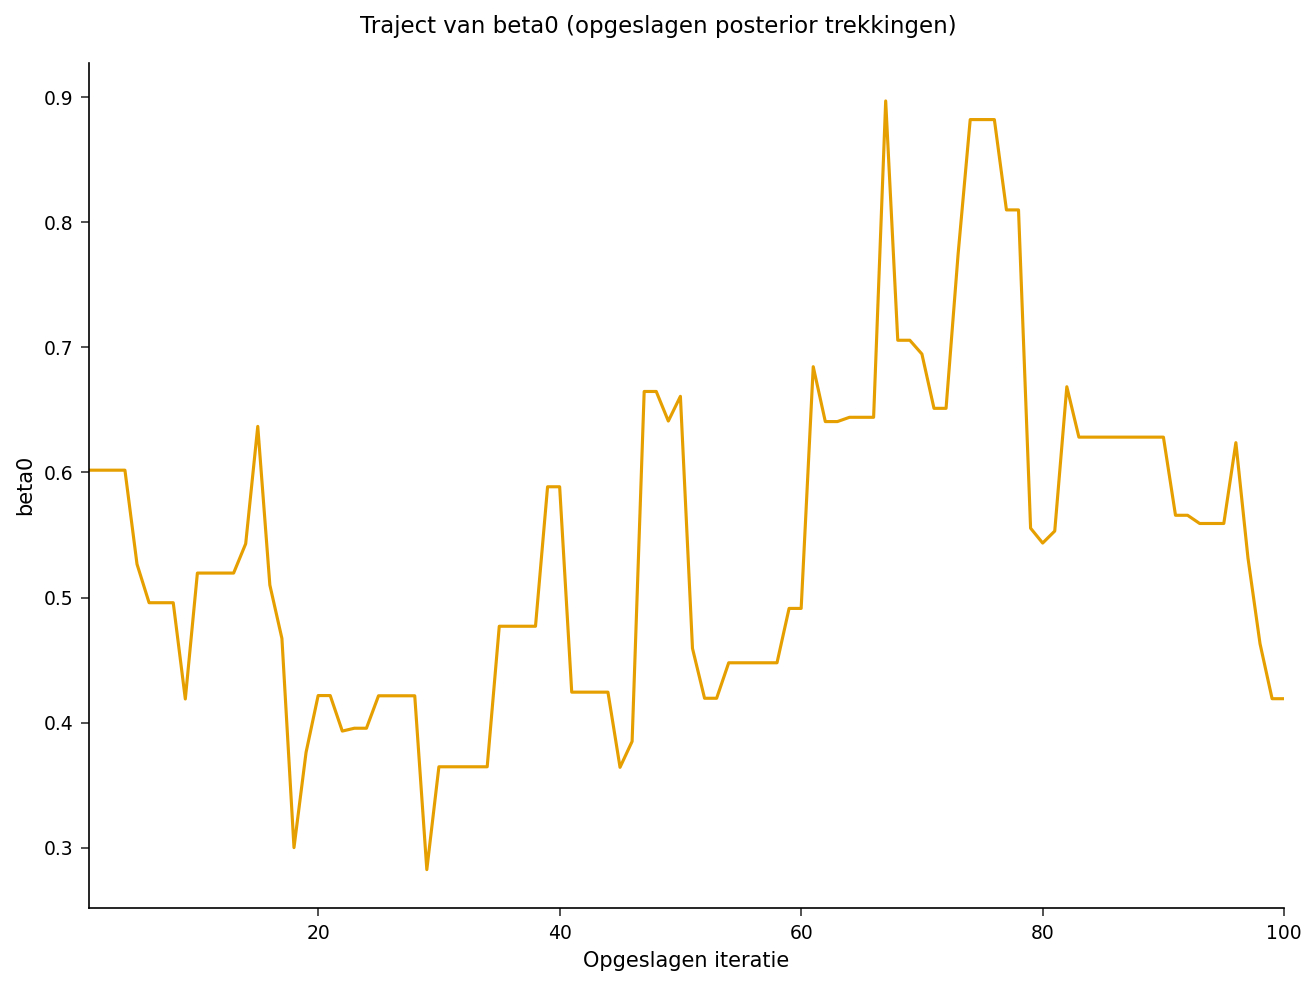

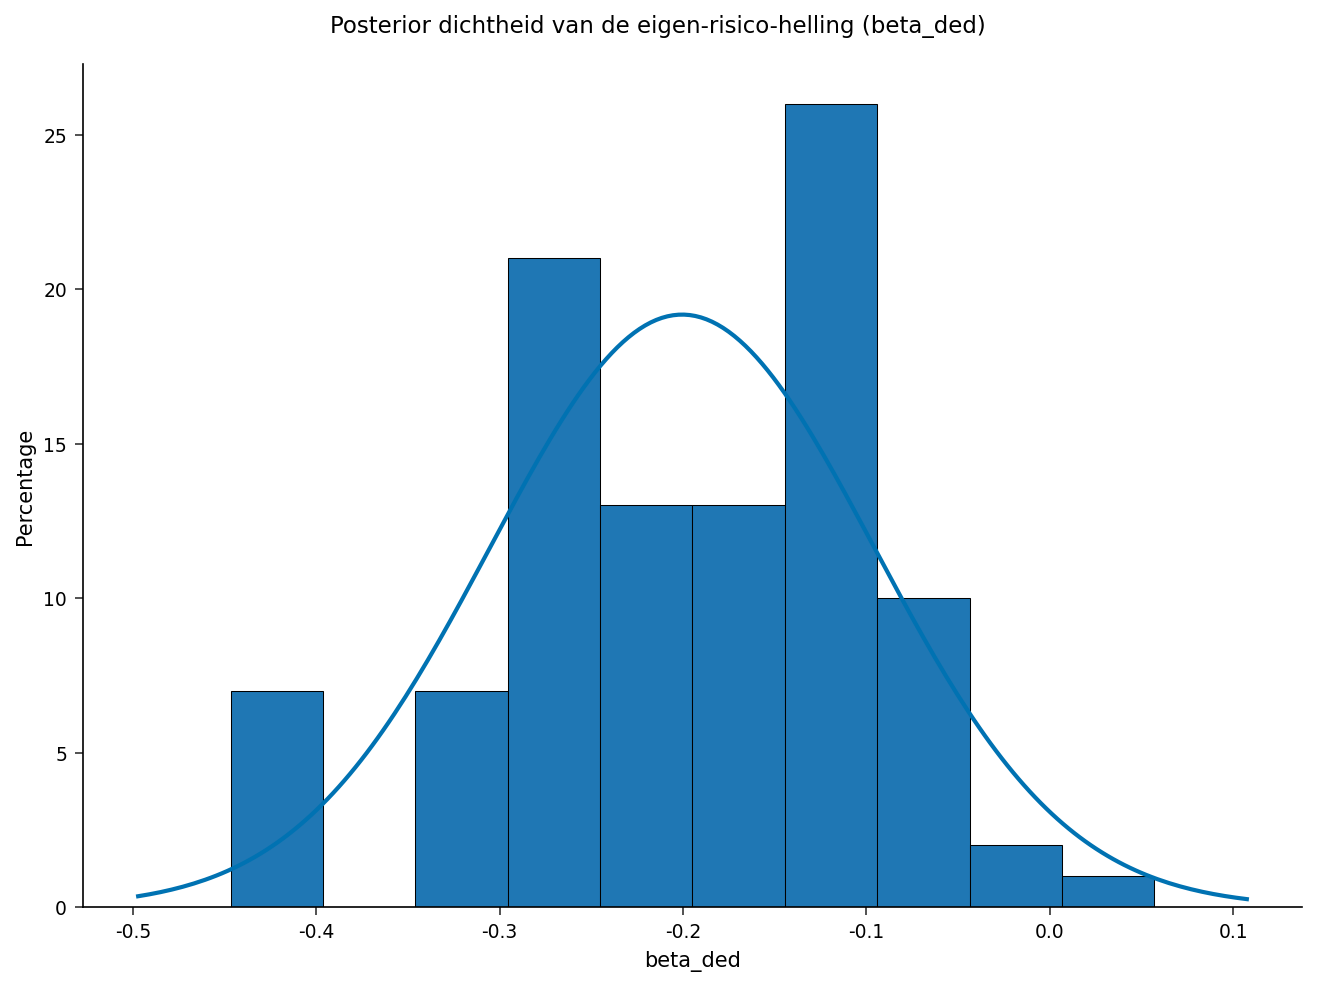

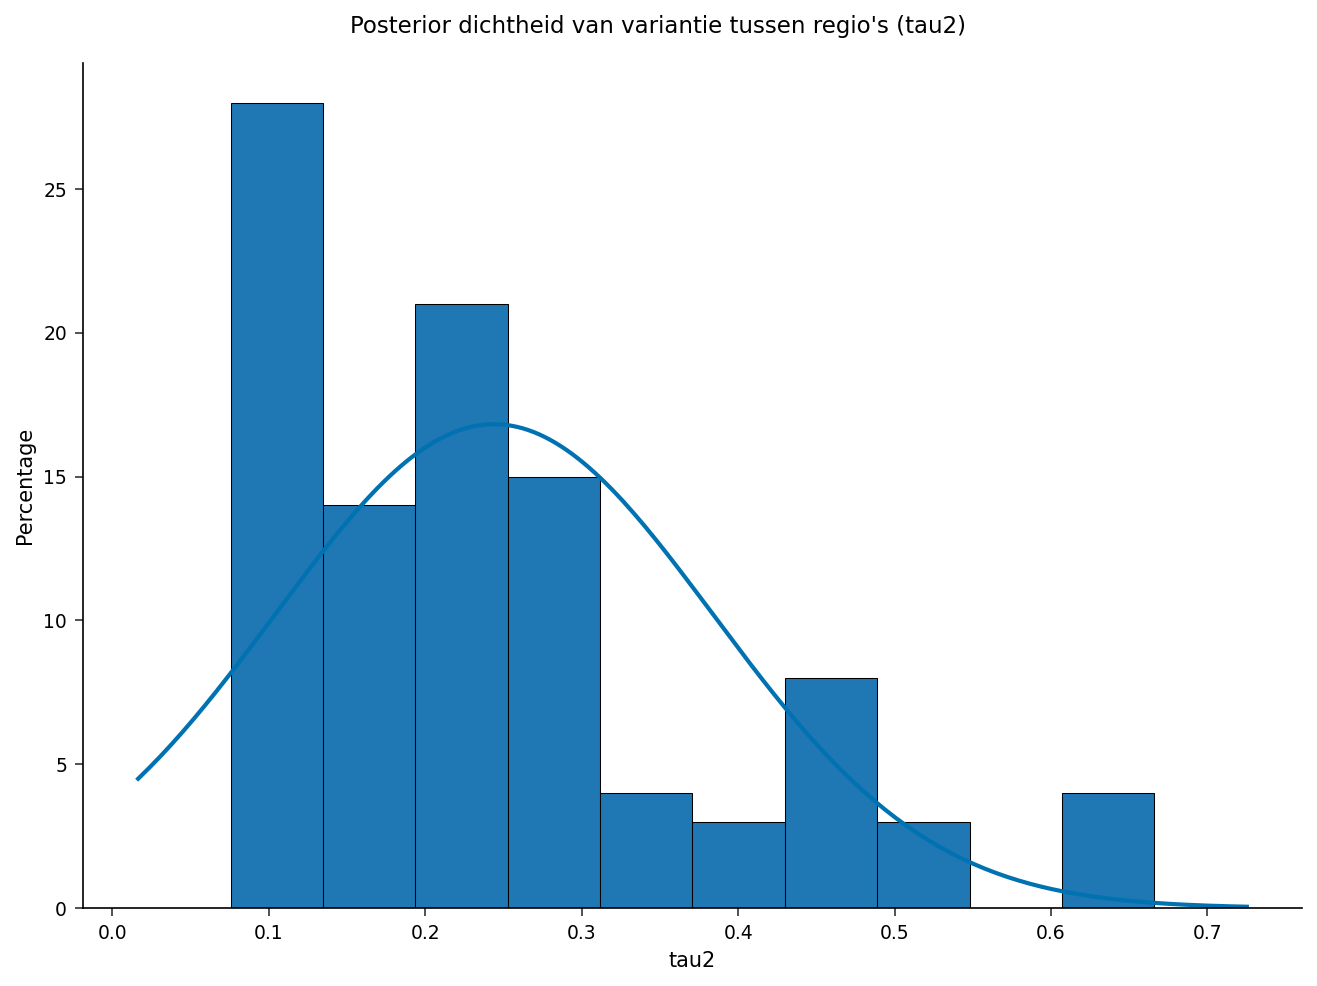

In [6]:
/* region_sd wordt hier toegevoegd aan post2, gebaseerd op de post-weergave uit Stap 4 */
GEGEVENS post2;
    INSTELLEN post;
    region_sd = sqrt(tau2);
UITVOEREN;

/* Traject van de basis-log-frequentie */
PROCEDURE SGPLOT GEGEVENS=post2;
    SERIES x=iter y=beta0;
    TITEL 'Traject van beta0 (opgeslagen posterior trekkingen)';
    XAXIS label='Opgeslagen iteratie';
    YAXIS label='beta0';
UITVOEREN;

/* Posterior dichtheid van de eigen-risico-helling */
PROCEDURE SGPLOT GEGEVENS=post2;
    HISTOGRAM beta_ded;
    DENSITY   beta_ded;
    TITEL 'Posterior dichtheid van de eigen-risico-helling (beta_ded)';
    XAXIS label='beta_ded';
    YAXIS label='Percentage';
UITVOEREN;

/* Posterior dichtheid van de variantie tussen regio's */
PROCEDURE SGPLOT GEGEVENS=post2;
    HISTOGRAM tau2;
    DENSITY   tau2;
    TITEL "Posterior dichtheid van variantie tussen regio's (tau2)";
    XAXIS label='tau2';
    YAXIS label='Percentage';
UITVOEREN;


## Interpretatie van de resultaten

**Wat het model opleverde:**

- **Teruggevonden structuur.** De posterior regio-effecten (`post_mean_u`) volgen de ingevoerde werkelijkheid (`true_eff`) in teken en volgorde: regio 5 (werkelijk +0,40) is het hoogst met +0,36, regio 4 (werkelijk -0,30) is het laagst met -0,70, en regio 1 (werkelijk +0,05) zit dicht bij het midden met +0,20. De eigen-risico-helling `beta_ded` komt uit op -0,13 (negatief, zoals het datagenererende proces specificeerde, al is deze door de kleine steekproef van 96 polissen richting nul gekrompen) en `beta0` herstelt een basis-log-frequentie van 0,43 — bewijs dat de hiërarchische Poisson-aannemelijkheid en de blootstellingsoffset correct zijn gespecificeerd.
- **Partiële pooling in de praktijk.** Vergelijk de gekrompen `relativity` uit Stap 4 met de ruwe frequenties uit Stap 2. Regio 5's ruwe frequentie van 3,41 wordt getrokken naar een relativiteit van 1,43, en regio 4's ruwe 0,45 stijgt naar een relativiteit van 0,49 — de dunbevolkte regio's worden naar het portefeuillemidden teruggehaald en dragen de **breedste geloofwaardigheidsintervallen**, precies het gedrag dat een actuaris wil: een gebied niet over- of onderprijzen op basis van een handvol toevallige schades.
- **Gekwantificeerde onzekerheid.** De posterior van `sqrt(tau2)` (gemiddeld ongeveer 0,48, berekend als het gemiddelde van de trekkingsgewijze wortel over de eerste 100 opgeslagen trekkingen) meet hoeveel echte heterogeniteit tussen regio's overblijft na correctie voor de eigen-risicomix en blootstelling — een directe input voor het vertrouwen in tariefgebied-relativiteiten en voor kapitaal-/reserve-onzekerheid.
- **Diagnostiek en modelfit.** De gerapporteerde **DIC is 246,7**, een maatstaf om deze hiërarchische specificatie te vergelijken met eenvoudigere, volledig gepoolde of volledig ongepoolde alternatieven. De effectieve steekproefgroottes zijn bescheiden (`beta_ded` bijna 525, de random effecten en `beta0` in de tientallen), en de **Geweke-diagnostiek markeert alle drie de gemonitorde parameters** — de trajectplot toont dat `beta0` over de eerste 100 opgeslagen trekkingen opwaarts drift. Met slechts 96 polisjaren en korte ketens in ongelicentieerde modus is deze niet-convergentie te verwachten; een productierun zou de burn-in en de bemonstering verlengen, en mogelijk herparametriseren, voordat op de intervallen wordt vertrouwd.

**Waarom Bayesiaans hier:** Frequentierelativiteiten voeden rechtstreeks de prijsstelling, en toezichthouders verwachten steeds vaker kwantificering van onzekerheid. PROC MCMC produceert de *volledige posterior* voor elke regio, zodat de verzekeraar bijvoorbeeld kan stellen: "de frequentierelativiteit van regio 4 heeft een 95%-geloofwaardigheidsinterval rond zijn posterior gemiddelde van 0,49" — een uitspraak die klassieke puntschattingen niet kunnen doen, en die het meest waardevol is juist voor de kleine, dataschaarse gebieden.